In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv

/home/sushant/Desktop/Gen Ai/LangGraph/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
load_dotenv()

True

In [5]:
class SubState(TypedDict):

    input_text: str
    translated_text: str

In [23]:
subgraph_llm = ChatGroq(model="openai/gpt-oss-120b")

In [7]:
def translate_text(state: SubState):

    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

In [8]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

In [9]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str
    

In [16]:
parent_llm = ChatGroq(model="openai/gpt-oss-120b")

In [18]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [19]:
def translate_answer(state: ParentState):

    # call the subgraph
    result = subgraph.invoke({'input_text': state['answer_eng']})

    return {'answer_hin': result['translated_text']}

In [20]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

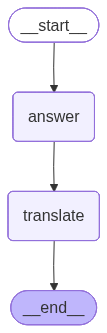

In [21]:
graph = parent_builder.compile()

graph


In [24]:
graph.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': '**Quantum physics** (also called quantum mechanics or quantum theory) is the branch of physics that describes how nature behaves at the smallest scales—typically at the level of atoms, electrons, photons, and other sub‑atomic particles.  \n\n---\n\n## Core ideas\n\n| Concept | What it means | Everyday analogy (if any) |\n|---------|---------------|---------------------------|\n| **Quantization** | Certain physical quantities (energy, angular momentum, charge) can only take on discrete values, not a continuous range. | Like a staircase: you can stand on step\u202f0,\u202f1,\u202f2…, but not in between. |\n| **Wave‑particle duality** | Particles such as electrons and photons exhibit both wave‑like (interference, diffraction) and particle‑like (localized impacts) behavior, depending on how they are measured. | A water wave can spread out, yet a single raindrop can hit a specific spot. |\n| **Superposition** | A quantum system can exi